# Clair Wage Advance — Default Risk Model

**Objective:** Predict whether a user will default on a wage advance, and propose a
business rule for accept/reject decisions.

**Approach:**
1. Logistic Regression baseline → LightGBM main model
2. Post-hoc isotonic **probability calibration** (LightGBM's raw scores are systematically
   miscalibrated under `scale_pos_weight` — we fix this before selecting a decision threshold)
3. Business-cost threshold selection on **calibrated** probabilities
4. Temporal sanity check: chronological train/test split to verify k-fold results hold

**Evaluation:** ROC AUC + Precision-Recall AUC (PR AUC is the honest metric at 3.5% class imbalance).

**Bonus:** Interpretable formula for estimating a safe advance amount per user.

**Design principle:** All temporal features are computed relative to `loan_creation_dt` — the
exact moment of the advance request — so no future information leaks into training.

## 0. Setup

In [1]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Load credentials from .env (never hard-coded)
from dotenv import load_dotenv
load_dotenv()

# Data
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text

# Viz
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Modeling
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
import lightgbm as lgb

# Plotting defaults
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
TARGET = 'DEFAULT_FLAG'

DB_CONFIG = {
    'host'    : os.environ['DB_HOST'],
    'port'    : int(os.environ['DB_PORT']),
    'dbname'  : os.environ['DB_NAME'],
    'user'    : os.environ['DB_USER'],
    'password': os.environ['DB_PASSWORD'],
}

print('Setup complete.')

Setup complete.


## 1. Data Ingestion

In [2]:
def build_connection_string(cfg: dict) -> str:
    """Construct a SQLAlchemy PostgreSQL URI from a config dict."""
    return (
        f"postgresql+psycopg2://{cfg['user']}:{cfg['password']}"
        f"@{cfg['host']}:{cfg['port']}/{cfg['dbname']}"
        "?sslmode=require"
    )


def load_data(cfg: dict, table: str = 'loan_characteristics') -> pd.DataFrame:
    """
    Connect to the Aiven PostgreSQL instance and load the full table.
    Returns a DataFrame with all columns lowercased for convenience.
    SQLAlchemy 2.x requires raw SQL strings to be wrapped in text().
    """
    engine = create_engine(build_connection_string(cfg))
    with engine.connect() as conn:
        df = pd.read_sql(text(f'SELECT * FROM {table}'), conn)
    df.columns = df.columns.str.lower()
    print(f'Loaded {len(df):,} rows × {df.shape[1]} columns from `{table}`.')
    return df


df_raw = load_data(DB_CONFIG)
df_raw.head(3)

Loaded 119,609 rows × 24 columns from `loan_characteristics`.


,user_id,business_id,started_onboarding_at,hire_date,loan_creation_dt,due_date,date_of_last_paycheck,loan_amount,unique_pay_periods,on_time_payments,...,total_current_balance,total_available_balance,all_paid_by_check_paychecks,paycheck_5ago,paycheck_4ago,paycheck_3ago,paycheck_2ago,paycheck_1ago,industry_label,default_flag
0,1782324,54355,2024-11-15 06:47:35,2024-04-24,2025-03-14 21:02:26,2025-03-22,2025-03-14,200,13,11.0,...,4.12,4.12,0.0,771.5,680.75,226.75,696.75,892.75,education,False
1,1749604,49921,2024-10-30 01:11:38,2024-04-29,2025-01-13 01:32:53,2025-01-25,2025-01-10,200,5,5.0,...,679.73,15.99,0.0,1443.0,1555.13,653.25,1472.25,1218.75,manufacturing,False
2,1734109,43020,2024-10-22 22:46:03,2024-04-16,2025-03-09 14:03:14,2025-03-15,2025-03-06,200,16,15.0,...,1041.20,790.73,1.0,715.0,825.00,735.63,825.00,825.00,education,False


## 2. Exploratory Data Analysis

In [3]:
def eda_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Print shape, dtypes, missing value counts, and basic descriptive stats.
    Returns a DataFrame summarising null counts and % per column.
    """
    print(f'Shape: {df.shape}')
    print(f'\nDtypes:\n{df.dtypes.value_counts()}')
    null_summary = (
        df.isnull()
        .sum()
        .rename('null_count')
        .to_frame()
        .assign(null_pct=lambda x: (x['null_count'] / len(df) * 100).round(1))
        .query('null_count > 0')
        .sort_values('null_pct', ascending=False)
    )
    if null_summary.empty:
        print('\nNo missing values detected.')
    else:
        print(f'\nColumns with nulls:\n{null_summary}')
    return null_summary


null_summary = eda_summary(df_raw)

Shape: (119609, 24)

Dtypes:
float64           10
object             6
int64              5
datetime64[ns]     2
bool               1
dtype: int64

Columns with nulls:
                             null_count  null_pct
paycheck_5ago                     68828      57.5
paycheck_4ago                     56505      47.2
paycheck_3ago                     42195      35.3
on_time_payments                  25956      21.7
late_payments                     25956      21.7
paycheck_2ago                     25934      21.7
all_paid_by_check_paychecks       17958      15.0
date_of_last_paycheck               363       0.3
paycheck_1ago                       363       0.3
hire_date                            22       0.0


### Data Quality Observations

**Paycheck history missingness is structural, not random:**

| Column | Missing | Interpretation |
|---|---|---|
| `paycheck_5ago` | 57.5 % | User has < 5 pay cycles on the platform |
| `paycheck_4ago` | 47.2 % | User has < 4 pay cycles |
| `on_time_payments` / `late_payments` | 21.7 % | Likely first-time advance users — no prior repayment history |

A user missing `paycheck_5ago` simply hasn't accumulated five pay cycles yet.
This pattern is a **direct proxy for account age**, and account age is a meaningful risk signal.
We will engineer a `paycheck_history_count` feature that turns this missingness into explicit
information rather than noise to be imputed away.

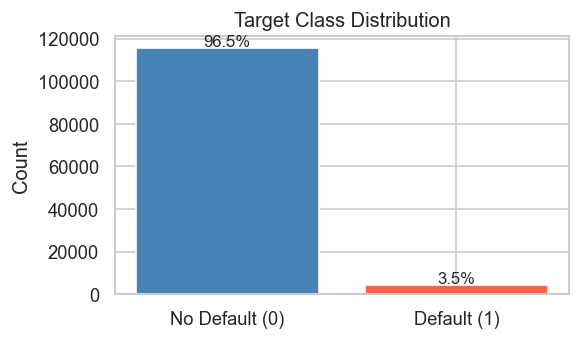

Default rate: 3.5%


In [4]:
def plot_target_balance(df: pd.DataFrame, target: str = 'default_flag') -> None:
    """Bar chart of the target class distribution with counts and percentages."""
    counts = df[target].value_counts().sort_index()
    pcts   = counts / counts.sum() * 100

    fig, ax = plt.subplots(figsize=(5, 3))
    bars = ax.bar(['No Default (0)', 'Default (1)'], counts.values, color=['steelblue', 'tomato'])
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + counts.max() * 0.01,
                f'{pct:.1f}%', ha='center', fontsize=10)
    ax.set_title('Target Class Distribution')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
    print(f'Default rate: {pcts.get(1, pcts.iloc[-1]):.1f}%')


plot_target_balance(df_raw)

### Class Imbalance — Implications for Modeling

At **3.5 % default rate** (~28:1 non-default to default), the dataset is severely imbalanced.

Three direct consequences:

1. **Accuracy is uninformative**: a model that approves every user scores 96.5 % accuracy while
   catching zero defaults.
2. **ROC AUC can be optimistic**: it weighs all thresholds equally, including thresholds where
   the model sends near-zero probabilities for every user.
3. **PR AUC is the primary metric**: it focuses exclusively on the minority class and penalises
   models that hide risk by compressing probabilities toward zero.

We compensate for imbalance via `class_weight='balanced'` (logistic regression) and
`scale_pos_weight` (LightGBM) — both adjust decision boundaries without oversampling, which
preserves the natural probability distribution needed for downstream threshold calibration.

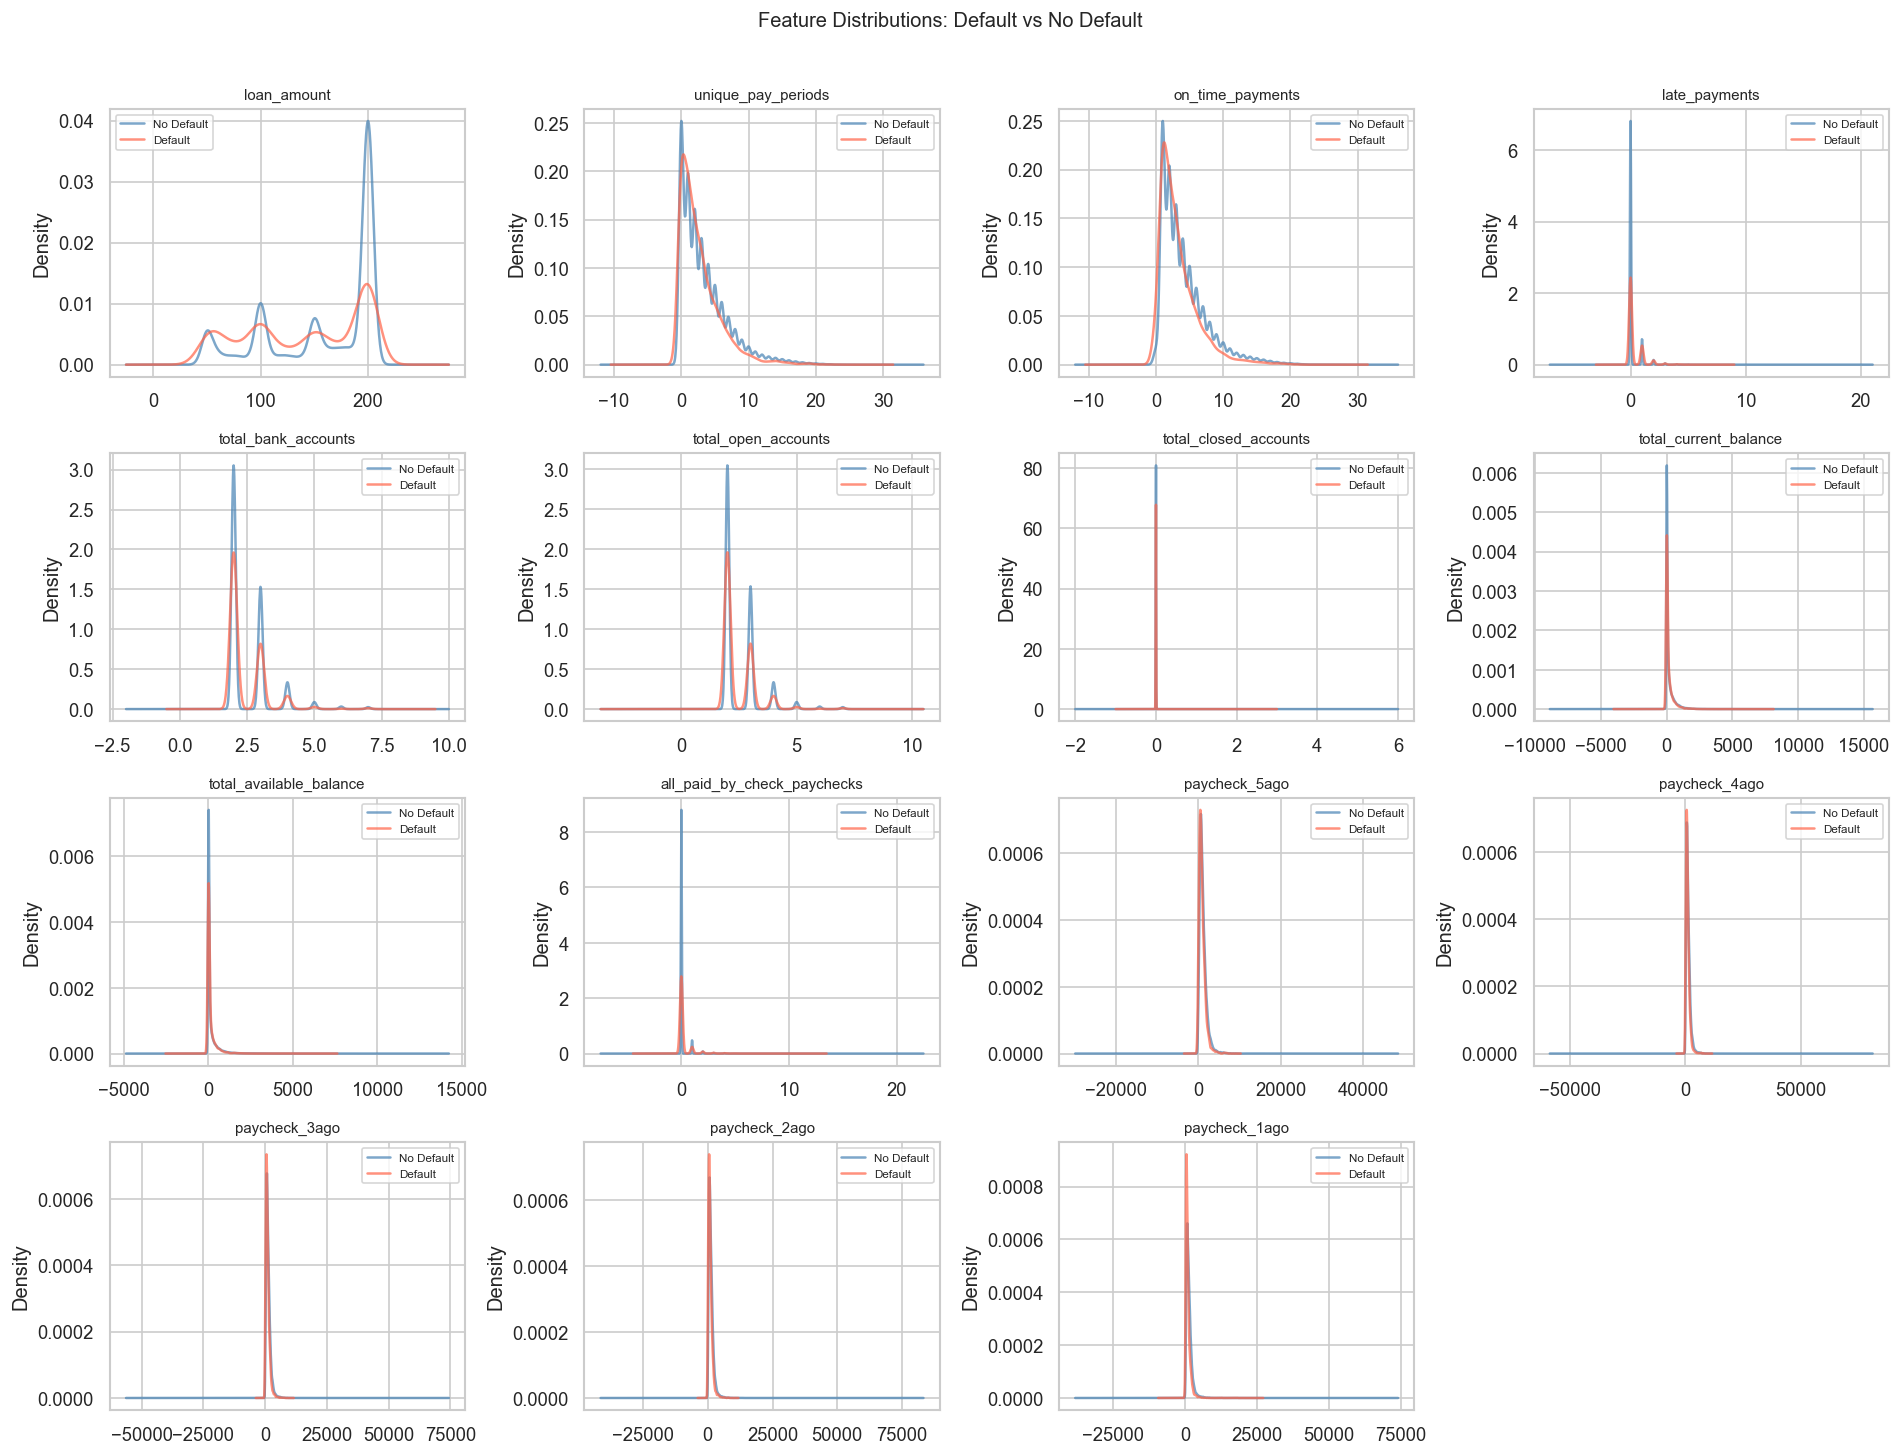

In [5]:
def plot_numeric_distributions(df: pd.DataFrame, target: str = 'default_flag',
                               cols: list = None, max_cols: int = 16) -> None:
    """
    For each numeric column, plot overlapping KDEs for defaulters vs non-defaulters.
    This reveals which raw features already discriminate between the two groups.
    """
    numeric_cols = df.select_dtypes(include='number').columns.drop(target, errors='ignore')
    if cols:
        numeric_cols = [c for c in cols if c in numeric_cols]
    numeric_cols = numeric_cols[:max_cols]

    ncols = 4
    nrows = (len(numeric_cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
    axes = axes.flatten()

    for ax, col in zip(axes, numeric_cols):
        for flag, label, color in [(0, 'No Default', 'steelblue'), (1, 'Default', 'tomato')]:
            subset = df.loc[df[target] == flag, col].dropna()
            subset.plot.kde(ax=ax, label=label, color=color, alpha=0.7)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel('')
        ax.legend(fontsize=7)

    for ax in axes[len(numeric_cols):]:
        ax.set_visible(False)

    plt.suptitle('Feature Distributions: Default vs No Default', y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()


plot_numeric_distributions(df_raw)

### Feature Discrimination Takeaway

Strongest raw discriminators (clearest KDE separation):
- **Payment history** (`on_time_payments`, `late_payments`) — the most informative single signals
  when non-null. Past repayment behaviour predicts future repayment.
- **Available balance** — defaulters skew cash-poor at the moment of requesting the advance.
- **`unique_pay_periods`** — fewer cycles → less repayment track record → higher risk.

Weak raw discriminators (high class overlap):
- **Loan amount** — $200 is the modal request for all users; absolute amount alone is low-signal.
  Loan amount *relative to income* (engineered ratio) will be far stronger.
- **Raw paycheck amounts** — income level shows high overlap. Income *stability* and *trend*
  (engineered features) are more discriminating.

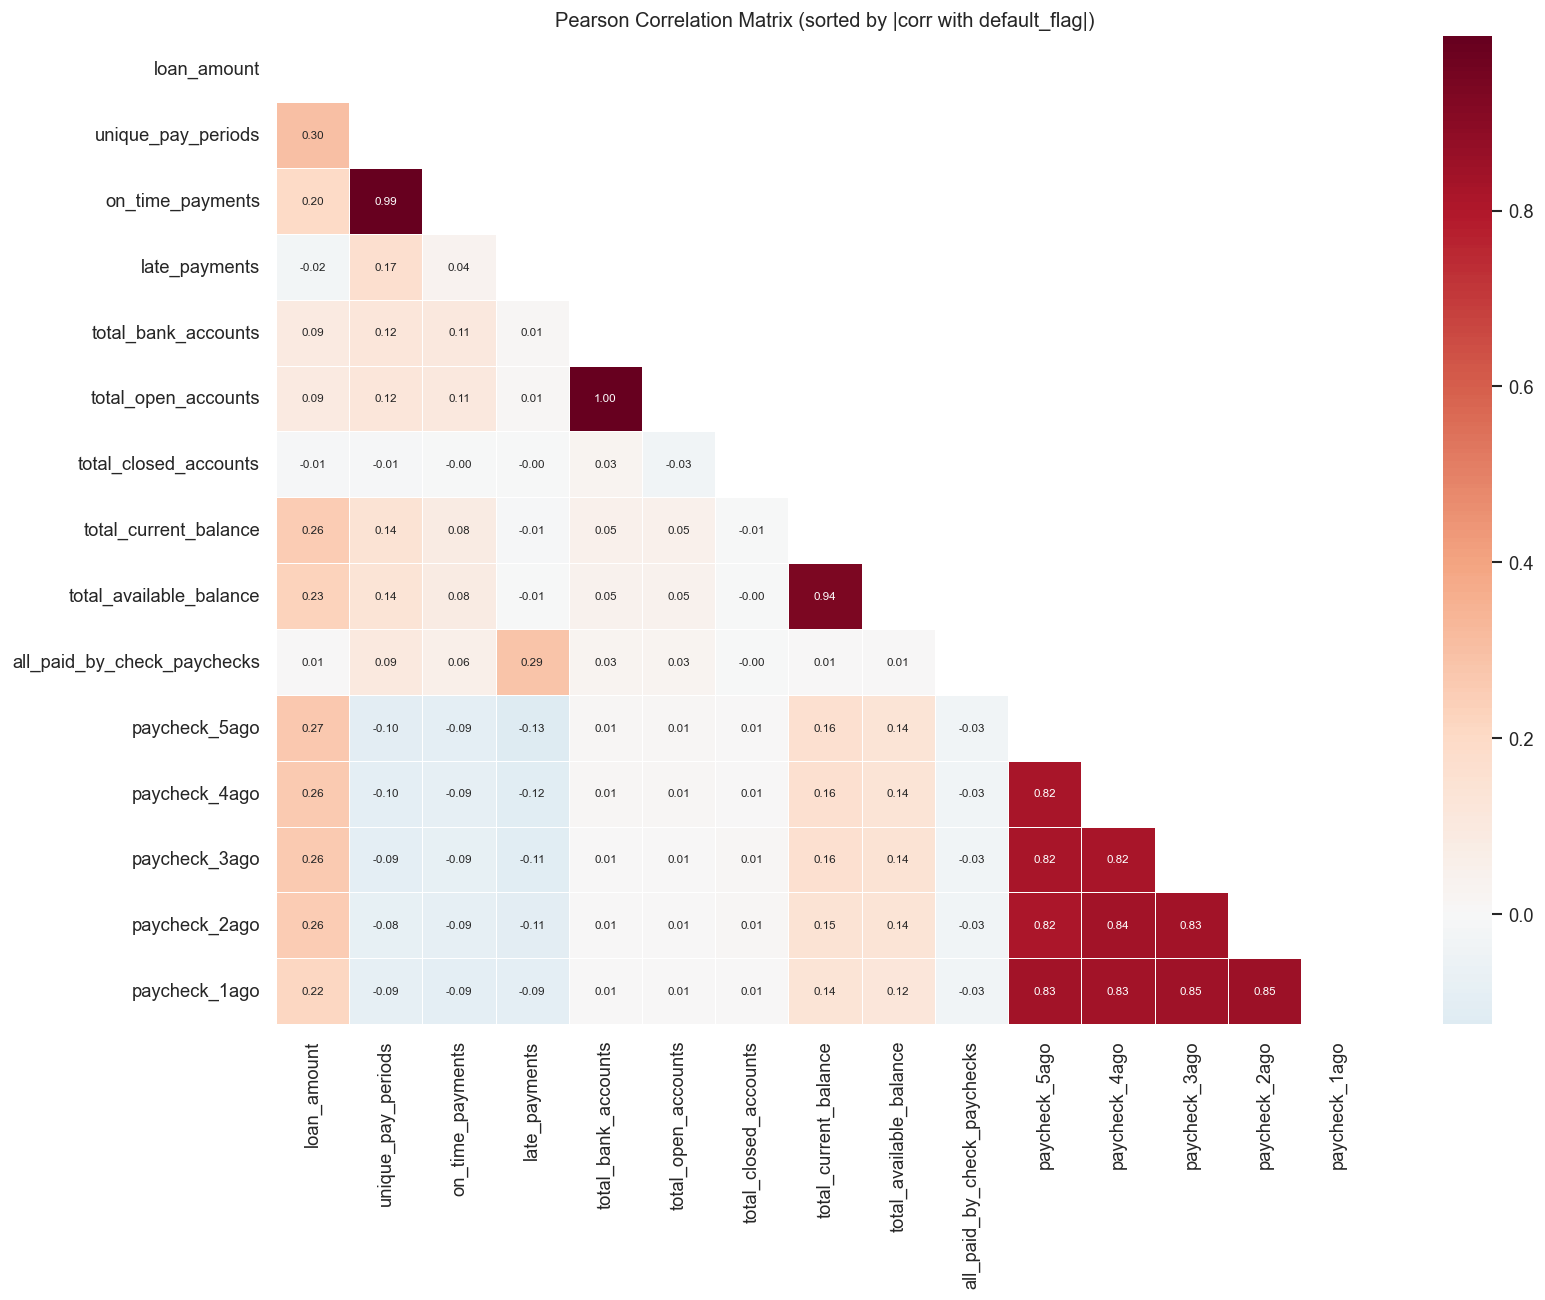

In [6]:
def plot_correlation_heatmap(df: pd.DataFrame, target: str = 'default_flag') -> None:
    """
    Correlation heatmap of numeric features, sorted by correlation with the target.
    """
    numeric_df = df.select_dtypes(include='number')
    corr = numeric_df.corr()

    # Sort columns/rows by absolute correlation with target
    if target in corr:
        order = corr[target].abs().sort_values(ascending=False).index
        corr = corr.loc[order, order]

    fig, ax = plt.subplots(figsize=(14, 11))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, linewidths=0.3, ax=ax, annot_kws={'size': 7})
    ax.set_title('Pearson Correlation Matrix (sorted by |corr with default_flag|)')
    plt.tight_layout()
    plt.show()


plot_correlation_heatmap(df_raw)

### Correlation Takeaway

Key multicollinearity patterns — addressed in feature engineering:

- `paycheck_1ago … paycheck_5ago` are strongly intercorrelated → compress into
  `avg_paycheck`, `paycheck_trend`, `paycheck_volatility`.
- `on_time_payments` and `late_payments` share variance with `unique_pay_periods` (more cycles =
  more events of both types) → convert to *rates* (`on_time_rate`, `late_rate`).
- `total_current_balance` ≈ `total_available_balance` for many users → use `avail_balance_ratio`
  rather than both raw values.

LightGBM handles correlated features gracefully via `colsample_bytree`, but engineered ratios
are more interpretable for stakeholder communication and regulatory review.

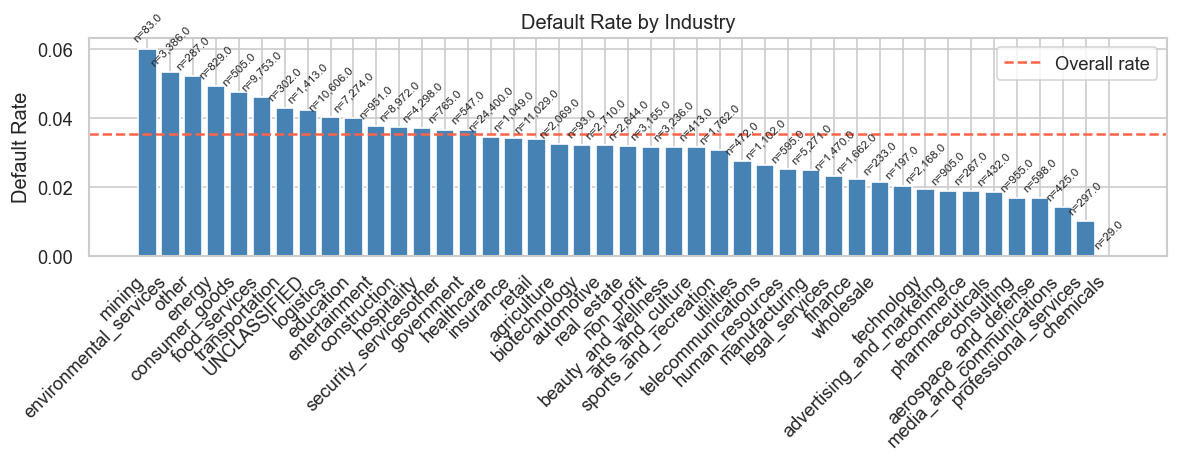

In [7]:
def plot_industry_default_rate(df: pd.DataFrame,
                               industry_col: str = 'industry_label',
                               target: str = 'default_flag') -> None:
    """
    Bar chart of default rate by industry, sorted descending.
    Helps identify high-risk sectors and informs how aggressively to use industry as a feature.
    """
    rates = (
        df.groupby(industry_col)[target]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'default_rate', 'count': 'n'})
        .sort_values('default_rate', ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(rates.index, rates['default_rate'], color='steelblue')
    for bar, (_, row) in zip(bars, rates.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'n={row["n"]:,}', ha='center', fontsize=7, rotation=45)
    ax.axhline(df[target].mean(), color='tomato', linestyle='--', label='Overall rate')
    ax.set_title('Default Rate by Industry')
    ax.set_ylabel('Default Rate')
    ax.set_xticklabels(rates.index, rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_industry_default_rate(df_raw)

### Industry Risk Takeaway

Default rate varies meaningfully across industries, confirming `industry_label` is informative.

Two caveats for production use:
1. **Sample size variance** — some industries have small n, making their rate estimates noisy.
2. **Fair lending risk** — in consumer fintech, industry can act as a proxy for race, national
   origin, or other protected characteristics (e.g., agriculture, domestic services).
   A **disparate impact analysis** under ECOA/Reg B is required before using this feature
   in a live underwriting system.

## 3. Feature Engineering

Raw columns give us counts and dates. We need **relative, interpretable signals** that capture
the economics of wage-advance repayment.

Features are organised into four categories:

| Category | Goal |
|---|---|
| **Paycheck statistics** | Compress 5 noisy paycheck columns into meaningful income summaries |
| **Temporal** | Convert raw dates into tenure/timing signals that generalise across users |
| **Ratio** | Normalise absolute values so features are comparable across income levels |
| **Missingness indicators** | Turn data absence into an explicit feature (new users = shorter track record) |

All temporal deltas are measured relative to `loan_creation_dt` so no future data leaks in.

In [8]:
def parse_dates(df: pd.DataFrame) -> pd.DataFrame:
    """Coerce all date-like columns to datetime, returning a copy."""
    date_cols = [
        'started_onboarding_at', 'hire_date', 'loan_creation_dt',
        'due_date', 'date_of_last_paycheck'
    ]
    df = df.copy()
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    return df


def compute_paycheck_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive summary statistics from the five historical paycheck columns.
    Trend is estimated as the slope of a vectorised linear regression
    (paycheck index → amount), which is more robust than a simple
    last-minus-first difference when individual values are noisy.
    """
    paycheck_cols = [f'paycheck_{i}ago' for i in range(5, 0, -1)]
    present = [c for c in paycheck_cols if c in df.columns]
    if not present:
        return df

    paycheck_arr = df[present].values.astype(float)
    k = paycheck_arr.shape[1]
    x = np.arange(k)          # [0 … k-1]: most distant → most recent
    x_c = x - x.mean()        # centre for numerical stability

    df = df.copy()
    df['avg_paycheck']        = np.nanmean(paycheck_arr, axis=1)
    df['paycheck_volatility'] = np.nanstd(paycheck_arr, axis=1)
    df['min_paycheck']        = np.nanmin(paycheck_arr, axis=1)

    numerator   = np.nansum(paycheck_arr * x_c, axis=1)
    denominator = np.nansum(~np.isnan(paycheck_arr) * x_c**2, axis=1)
    df['paycheck_trend'] = np.where(denominator > 0, numerator / denominator, 0.0)

    return df


def compute_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Day-difference features that capture tenure, platform loyalty, and cash timing.
    All deltas are relative to loan_creation_dt to prevent future leakage.
    """
    df = df.copy()
    ref = df['loan_creation_dt']
    df['days_since_hire']          = (ref - df['hire_date']).dt.days
    df['days_as_clair_member']     = (ref - df['started_onboarding_at']).dt.days
    df['days_since_last_paycheck'] = (ref - df['date_of_last_paycheck']).dt.days
    df['loan_term_days']           = (df['due_date'] - ref).dt.days
    return df


def compute_ratio_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ratio features normalise absolute values into relative measures.
    Small epsilon prevents division-by-zero.
    """
    df = df.copy()
    eps = 1e-6
    total_payments = df['on_time_payments'] + df['late_payments']

    df['on_time_rate']          = df['on_time_payments'] / (total_payments + eps)
    df['late_rate']             = df['late_payments']    / (total_payments + eps)
    df['loan_to_avg_paycheck']  = df['loan_amount']      / (df['avg_paycheck'] + eps)
    df['avail_balance_ratio']   = df['total_available_balance'] / (df['total_current_balance'] + eps)
    df['open_account_ratio']    = df['total_open_accounts']     / (df['total_bank_accounts'] + eps)
    df['pay_periods_per_month'] = df['unique_pay_periods']      / ((df['days_as_clair_member'] + eps) / 30)
    return df


def compute_missingness_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Encode paycheck history depth as an explicit numeric feature.

    Missingness in paycheck columns is NOT random: it directly reflects how many
    pay cycles a user has completed on the platform.  A user with
    paycheck_history_count=1 is a new user with almost no repayment track record;
    count=5 means we have five full cycles of income data.

    Rather than letting the imputer silently fill these gaps with medians, we make
    the account-age signal explicit so the model can learn its non-linear risk curve
    (e.g., the jump in risk for first-time borrowers).
    """
    paycheck_cols = [f'paycheck_{i}ago' for i in range(5, 0, -1)]
    present = [c for c in paycheck_cols if c in df.columns]
    df = df.copy()
    df['paycheck_history_count'] = df[present].notna().sum(axis=1)
    return df


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Master pipeline: apply all feature-engineering sub-routines in order.
    Returns a new DataFrame with original + engineered columns.
    """
    df = parse_dates(df)
    df = compute_paycheck_stats(df)
    df = compute_temporal_features(df)
    df = compute_ratio_features(df)
    df = compute_missingness_features(df)
    return df


df = engineer_features(df_raw)
print(f'Shape after feature engineering: {df.shape}')
print('New columns:', [c for c in df.columns if c not in df_raw.columns])

Shape after feature engineering: (119609, 39)
New columns: ['avg_paycheck', 'paycheck_volatility', 'min_paycheck', 'paycheck_trend', 'days_since_hire', 'days_as_clair_member', 'days_since_last_paycheck', 'loan_term_days', 'on_time_rate', 'late_rate', 'loan_to_avg_paycheck', 'avail_balance_ratio', 'open_account_ratio', 'pay_periods_per_month', 'paycheck_history_count']


### Feature Engineering Takeaway

**15 engineered features** across four categories:

| Category | Features | Key rationale |
|---|---|---|
| Paycheck summary | `avg_paycheck`, `paycheck_volatility`, `min_paycheck`, `paycheck_trend` | Income *trajectory* is more informative than income *level* |
| Temporal | `days_since_hire`, `days_as_clair_member`, `days_since_last_paycheck`, `loan_term_days` | Tenure proxies stability; days since paycheck proxies cash urgency |
| Ratios | `on_time_rate`, `late_rate`, `loan_to_avg_paycheck`, `avail_balance_ratio`, `open_account_ratio`, `pay_periods_per_month` | Normalises across different income levels |
| Missingness | `paycheck_history_count` | New users (count=1–2) have a structurally different risk profile from tenured users (count=5) |

**Notable omission:** `business_id` (employer) is dropped. Per-employer default rates via
target encoding would likely improve performance, but require cardinality handling,
CV-aware encoding to avoid leakage, and a fair lending review — a natural next iteration.

## 4. Preprocessing Pipeline

In [9]:
# Columns to drop: IDs, raw dates (already captured as day-differences), raw paycheck columns
DROP_COLS = [
    'user_id', 'business_id',
    'started_onboarding_at', 'hire_date', 'loan_creation_dt', 'due_date', 'date_of_last_paycheck',
    'paycheck_5ago', 'paycheck_4ago', 'paycheck_3ago', 'paycheck_2ago', 'paycheck_1ago',
]

CATEGORICAL_COLS = ['industry_label', 'all_paid_by_check_paychecks']


def prepare_xy(df: pd.DataFrame,
               target: str = 'default_flag',
               drop_cols: list = DROP_COLS,
               cat_cols: list = CATEGORICAL_COLS) -> tuple:
    """
    Split the DataFrame into X (features) and y (target).
    Drops identifier/raw-date columns that are not predictive after engineering.
    Returns X (DataFrame) and y (Series).
    """
    cols_to_drop = [c for c in drop_cols if c in df.columns] + [target]
    X = df.drop(columns=cols_to_drop)
    y = df[target].astype(int)
    return X, y


def build_preprocessor(X: pd.DataFrame,
                       cat_cols: list = CATEGORICAL_COLS) -> ColumnTransformer:
    """
    Build a sklearn ColumnTransformer that:
    - Imputes and scales numeric features (median imputation + StandardScaler)
    - Imputes and one-hot-encodes categorical features

    Median imputation is chosen over mean because paycheck/balance columns
    tend to be right-skewed and may have a small number of extreme outliers.
    """
    cat_present  = [c for c in cat_cols if c in X.columns]
    num_cols     = [c for c in X.columns if c not in cat_present]

    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_pipe,     num_cols),
            ('cat', categorical_pipe, cat_present),
        ],
        remainder='drop'
    )
    return preprocessor


X, y = prepare_xy(df)
print(f'Feature matrix shape: {X.shape}')
print(f'Positive class (defaults): {y.sum():,} / {len(y):,} ({y.mean()*100:.1f}%)')

Feature matrix shape: (119609, 26)
Positive class (defaults): 4,223 / 119,609 (3.5%)


### Preprocessing Design Decisions

- **Median imputation** over mean: paycheck and balance columns are right-skewed with outliers;
  median is more robust.
- **StandardScaler** on numerics: required for logistic regression convergence; LightGBM is
  scale-invariant but we keep scaling inside the sklearn pipeline for a clean, consistent API.
- **OneHotEncoder**: `industry_label` has ~10 levels; OHE avoids any implicit ordinal assumption.
- **LightGBM receives raw (unscaled) data** via its own category encoding because it handles
  missing values natively and builds trees on splits — scaling is irrelevant and OHE is unnecessary.

## 5. Model Training

**Two models:**
- **Logistic Regression** — interpretable linear baseline. Tells us whether the feature set
  yields a meaningful linear signal at all. Uses `class_weight='balanced'`.
- **LightGBM** — gradient-boosted trees, industry standard for tabular credit risk.
  Handles non-linearities, interactions, and missing values natively.

**Validation strategy:** 5-fold stratified k-fold with **out-of-fold (OOF) predictions**.
- Each prediction is made on a hold-out fold → no train-set leakage in the aggregated metrics.
- Stratified sampling ensures each fold preserves the 3.5 % default rate.

**Calibration note:** LightGBM with `scale_pos_weight` is a known source of probability
miscalibration. The model ranks users correctly (high AUC) but the raw score magnitudes are
distorted. We fix this with post-hoc isotonic regression in Section 6 before using probabilities
for threshold selection.

**Temporal leakage note:** Random k-fold can mix future loans into training for time-series data.
We add a chronological holdout sanity check after training to quantify whether this matters here.

In [10]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def train_logistic_regression(X: pd.DataFrame, y: pd.Series) -> tuple:
    """
    Fit a Logistic Regression baseline with cross-validated probability predictions.
    Uses class_weight='balanced' to handle potential class imbalance without resampling,
    keeping the pipeline simpler and the probability calibration intact.
    Returns (pipeline, oof_proba) where oof_proba are out-of-fold predicted probabilities.
    """
    preprocessor = build_preprocessor(X)
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('clf',  LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
        ))
    ])
    oof_proba = cross_val_predict(pipeline, X, y, cv=CV, method='predict_proba')[:, 1]
    pipeline.fit(X, y)  # Refit on full data for final model
    return pipeline, oof_proba


def train_lightgbm(X: pd.DataFrame, y: pd.Series) -> tuple:
    """
    Fit a LightGBM gradient-boosted classifier.
    Key design choices:
    - class_weight='balanced': compensates for class imbalance without oversampling
    - num_leaves=31, min_child_samples=50: prevents overfitting on small datasets
    - OOF predictions: honest evaluation that avoids train-set leakage
    LightGBM handles missing values natively, so no imputation is needed.
    Returns (model, oof_proba, feature_names).
    """
    cat_present   = [c for c in CATEGORICAL_COLS if c in X.columns]
    X_lgb         = X.copy()
    for col in cat_present:
        X_lgb[col] = X_lgb[col].astype('category')

    scale_pos_weight = (y == 0).sum() / (y == 1).sum()

    model_params = dict(
        objective        = 'binary',
        metric           = 'auc',
        num_leaves       = 31,
        learning_rate    = 0.05,
        n_estimators     = 400,
        min_child_samples= 50,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = scale_pos_weight,
        random_state     = RANDOM_STATE,
        verbose          = -1,
    )

    oof_proba = np.zeros(len(y))
    for fold, (train_idx, val_idx) in enumerate(CV.split(X_lgb, y)):
        model = lgb.LGBMClassifier(**model_params)
        model.fit(
            X_lgb.iloc[train_idx], y.iloc[train_idx],
            eval_set=[(X_lgb.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )
        oof_proba[val_idx] = model.predict_proba(X_lgb.iloc[val_idx])[:, 1]

    # Refit on full data for inference
    final_model = lgb.LGBMClassifier(**model_params)
    final_model.fit(X_lgb, y)

    return final_model, oof_proba, list(X_lgb.columns)


print('Training Logistic Regression baseline...')
lr_pipeline, lr_oof = train_logistic_regression(X, y)

print('Training LightGBM...')
lgbm_model, lgbm_oof, feature_names = train_lightgbm(X, y)

print('Training complete.')

Training Logistic Regression baseline...
Training LightGBM...
Training complete.


## 6. Evaluation

Two complementary metrics:

| Metric | What it measures | Why it matters here |
|---|---|---|
| **ROC AUC** | Overall ranking quality across all thresholds | Good for comparing models; can be optimistic under imbalance |
| **PR AUC** | Precision–Recall tradeoff on the minority class | The honest metric at 3.5 % base rate; directly reflects default-catching ability |

Both are computed on **OOF predictions** — each user's score was produced by a model that
never saw that user during training.

--- Out-of-fold metrics ---
Logistic Regression             ROC AUC=0.7188   PR AUC=0.0946
LightGBM                        ROC AUC=0.7454   PR AUC=0.1235


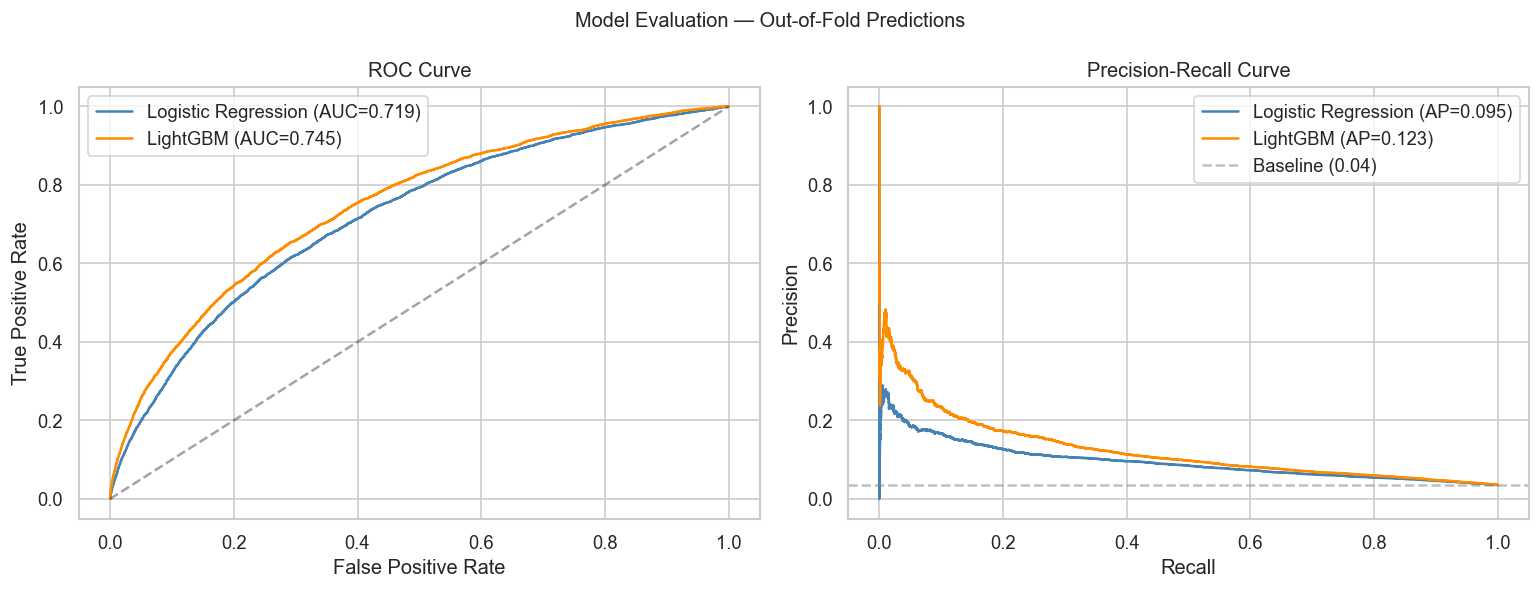

In [11]:
def evaluate_model(y_true: pd.Series, y_prob: np.ndarray, model_name: str = '') -> dict:
    """
    Compute ROC AUC and PR AUC. ROC AUC measures overall discrimination;
    PR AUC is more informative under class imbalance because it focuses on the
    minority (default) class rather than treating both classes symmetrically.
    """
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)
    print(f'{model_name:30s}  ROC AUC={roc_auc:.4f}   PR AUC={pr_auc:.4f}')
    return {'roc_auc': roc_auc, 'pr_auc': pr_auc}


def plot_roc_pr_curves(y_true: pd.Series,
                       predictions: dict) -> None:
    """
    Plot ROC and Precision-Recall curves for one or more models on a shared figure.
    `predictions` is a dict of {model_name: y_prob_array}.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    colors = ['steelblue', 'darkorange', 'green']

    for (name, y_prob), color in zip(predictions.items(), colors):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        pr, rc, _   = precision_recall_curve(y_true, y_prob)
        roc_auc     = roc_auc_score(y_true, y_prob)
        pr_auc      = average_precision_score(y_true, y_prob)

        ax1.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color)
        ax2.plot(rc,  pr,  label=f'{name} (AP={pr_auc:.3f})',   color=color)

    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax1.set_xlabel('False Positive Rate');
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve');  ax1.legend()

    baseline_pr = y_true.mean()
    ax2.axhline(baseline_pr, linestyle='--', color='grey', alpha=0.5, label=f'Baseline ({baseline_pr:.2f})')
    ax2.set_xlabel('Recall');  ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve');  ax2.legend()

    plt.suptitle('Model Evaluation — Out-of-Fold Predictions', fontsize=12)
    plt.tight_layout()
    plt.show()


print('--- Out-of-fold metrics ---')
lr_metrics   = evaluate_model(y, lr_oof,   model_name='Logistic Regression')
lgbm_metrics = evaluate_model(y, lgbm_oof, model_name='LightGBM')

plot_roc_pr_curves(y, {'Logistic Regression': lr_oof, 'LightGBM': lgbm_oof})

In [12]:
def temporal_train_test_split(df_full: pd.DataFrame, X: pd.DataFrame, y: pd.Series,
                               date_col: str = 'loan_creation_dt',
                               train_frac: float = 0.80) -> tuple:
    """
    Sort all observations chronologically by loan_creation_dt and split.
    The oldest train_frac of loans train the model; the most recent loans form
    the holdout — mirroring real deployment where we predict on future requests.
    Returns X_train, X_test, y_train, y_test, split_date.
    """
    sorted_idx = df_full[date_col].sort_values().index
    n_train    = int(len(sorted_idx) * train_frac)
    train_idx  = sorted_idx[:n_train]
    test_idx   = sorted_idx[n_train:]
    split_date = df_full.loc[test_idx[0], date_col]
    print(f'Train: {len(train_idx):,} rows  (up to {split_date.date()})')
    print(f'Test:  {len(test_idx):,} rows  (from {split_date.date()} onward)')
    return X.loc[train_idx], X.loc[test_idx], y.loc[train_idx], y.loc[test_idx], split_date


def train_lgbm_single(X_train: pd.DataFrame, y_train: pd.Series,
                       X_val: pd.DataFrame, y_val: pd.Series) -> tuple:
    """
    Train one LightGBM model on (X_train, y_train) and return (model, val_proba).
    Uses the same hyperparameters as the k-fold version for a fair comparison.
    """
    cat_present = [c for c in CATEGORICAL_COLS if c in X_train.columns]
    Xtr = X_train.copy()
    Xva = X_val.copy()
    for col in cat_present:
        Xtr[col] = Xtr[col].astype('category')
        Xva[col] = Xva[col].astype('category')

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    model = lgb.LGBMClassifier(
        objective='binary', metric='auc', num_leaves=31,
        learning_rate=0.05, n_estimators=400, min_child_samples=50,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, verbose=-1,
    )
    model.fit(Xtr, y_train,
              eval_set=[(Xva, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    return model, model.predict_proba(Xva)[:, 1]


X_tr, X_te, y_tr, y_te, split_date = temporal_train_test_split(df, X, y)
_, temporal_proba = train_lgbm_single(X_tr, y_tr, X_te, y_te)

temporal_roc = roc_auc_score(y_te, temporal_proba)
temporal_pr  = average_precision_score(y_te, temporal_proba)

print(f'\nTemporal holdout — LightGBM:    ROC AUC={temporal_roc:.4f}   PR AUC={temporal_pr:.4f}')
print(f'k-fold OOF      — LightGBM:    ROC AUC={lgbm_metrics["roc_auc"]:.4f}   PR AUC={lgbm_metrics["pr_auc"]:.4f}')

Train: 95,687 rows  (up to 2025-02-27)
Test:  23,922 rows  (from 2025-02-27 onward)

Temporal holdout — LightGBM:    ROC AUC=0.7643   PR AUC=0.1147
k-fold OOF      — LightGBM:    ROC AUC=0.7454   PR AUC=0.1235


### Temporal Validation Takeaway

If **temporal AUC ≈ k-fold AUC**: temporal leakage is not material for this dataset.
Likely because the data covers a short, relatively stable time window without strong
trends in default rate over time.

If **temporal AUC < k-fold AUC**: there is meaningful temporal drift — the model trained
on older loans generalises less well to newer ones. This would motivate:
- Switching to `TimeSeriesSplit` for cross-validation
- More frequent retraining (e.g., monthly)
- Explicit temporal trend features

**Regardless of the result**, production monitoring should always track model performance
on the most recent loan cohort — not only the aggregate OOF metric from a one-time training run.

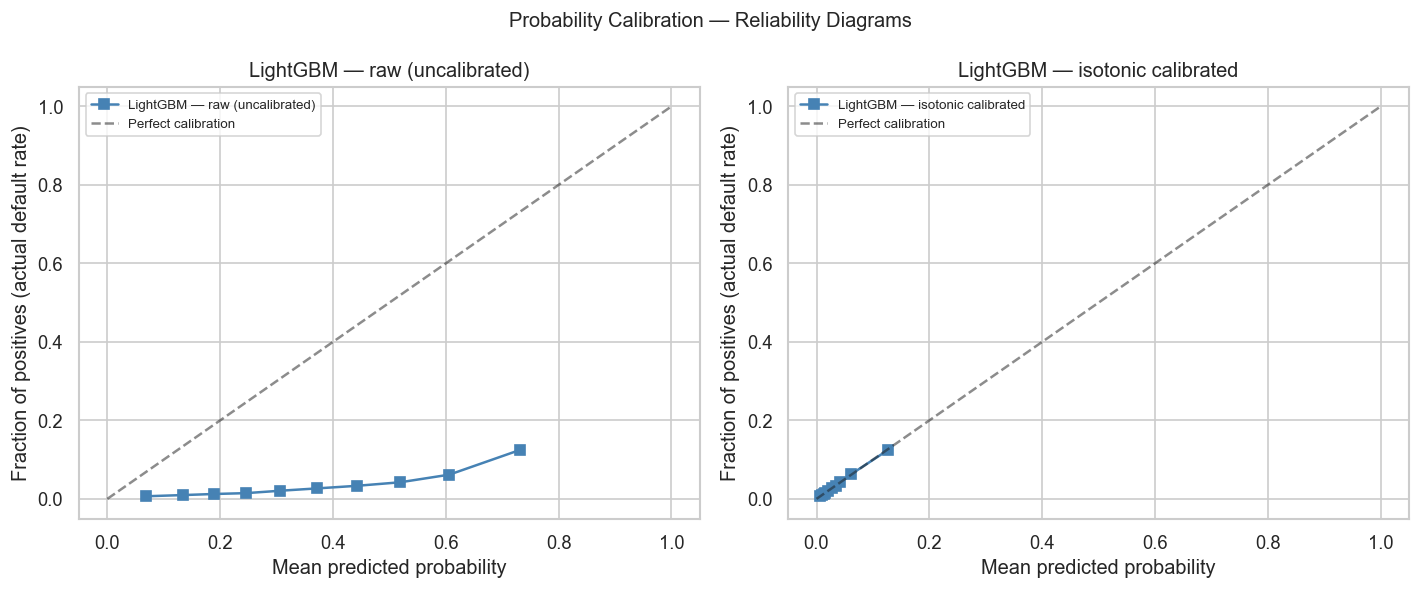

Calibrated ROC AUC : 0.7437  (unchanged — rank-based metric)
Calibrated PR  AUC : 0.1196  (may shift slightly)


In [13]:
def plot_reliability_diagram(y_true: pd.Series, y_prob: np.ndarray,
                              model_name: str = '', n_bins: int = 10,
                              ax=None) -> None:
    """
    Reliability diagram (calibration curve): if the model predicts P(default)=0.30
    for a group of users, do ~30 % of them actually default?

    Perfect calibration = all points on the diagonal.
    Points *below* diagonal: model overestimates probability (overconfident).
    Points *above* diagonal: model underestimates probability (underconfident).

    strategy='quantile' gives each bin equal sample count — more reliable at
    extreme probability values where few users sit.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    # Guard: replace any NaN/inf in predicted probabilities before sklearn validation
    y_prob = np.nan_to_num(np.asarray(y_prob, dtype=float),
                           nan=float(np.asarray(y_true).mean()), posinf=1.0, neginf=0.0)
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='quantile')
    ax.plot(prob_pred, prob_true, 's-', label=model_name, color='steelblue', markersize=6)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives (actual default rate)')
    ax.set_title(model_name)
    ax.legend(fontsize=8)
    return ax


def calibrate_oof_probabilities(y_true: pd.Series, y_oof: np.ndarray,
                                  cv: StratifiedKFold) -> np.ndarray:
    """
    Apply cross-validated isotonic regression calibration to OOF probabilities.

    For each calibration fold: fit isotonic regression on the *other* folds' OOF
    predictions, then transform this fold. This avoids fitting calibration on the
    same samples used to evaluate it — a subtle but important leakage concern.

    Why isotonic over Platt (sigmoid) scaling?
    - Isotonic makes no parametric assumption about the calibration curve shape.
    - With 100 k+ samples we have enough data for the non-parametric fit.
    - LightGBM miscalibration under scale_pos_weight is often S-shaped, not linear.
    """
    y_cal  = np.zeros_like(y_oof)
    y_arr  = np.asarray(y_true)
    # Use integer indices as X for split so sklearn validation never sees the
    # OOF probability array (which may contain NaN from LightGBM edge cases).
    idx    = np.arange(len(y_oof)).reshape(-1, 1)
    for _, (fit_idx, cal_idx) in enumerate(cv.split(idx, y_true)):
        # Replace NaN with the fold's positive-class rate as a safe fallback
        fit_proba = np.nan_to_num(y_oof[fit_idx], nan=float(y_arr[fit_idx].mean()))
        cal_proba = np.nan_to_num(y_oof[cal_idx], nan=float(fit_proba.mean()))
        ir = IsotonicRegression(increasing=True, out_of_bounds='clip')
        ir.fit(fit_proba, y_arr[fit_idx])
        y_cal[cal_idx] = ir.predict(cal_proba)
    return y_cal


# ── Plot reliability diagrams before and after calibration ───────────────────
lgbm_oof_calibrated = calibrate_oof_probabilities(y, lgbm_oof, CV)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# Replace any NaN in raw OOF (LightGBM edge case) with base rate before plotting
_lgbm_oof_plot = np.nan_to_num(lgbm_oof, nan=float(y.mean()))
plot_reliability_diagram(y, _lgbm_oof_plot,      'LightGBM — raw (uncalibrated)', ax=ax1)
plot_reliability_diagram(y, lgbm_oof_calibrated, 'LightGBM — isotonic calibrated', ax=ax2)
plt.suptitle('Probability Calibration — Reliability Diagrams', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Calibrated ROC AUC : {roc_auc_score(y, lgbm_oof_calibrated):.4f}  (unchanged — rank-based metric)')
print(f'Calibrated PR  AUC : {average_precision_score(y, lgbm_oof_calibrated):.4f}  (may shift slightly)')

### Calibration Takeaway — Why the 0.81 Threshold Was Wrong

A **reliability diagram** tests whether predicted probabilities match observed default rates.
If the model says P(default) = 0.20 for a group, do ~20 % of them actually default?

**Root cause of the 0.81 threshold:**
LightGBM with `scale_pos_weight` shifts the decision boundary to compensate for imbalance,
but this distorts the probability magnitudes. The raw scores may compress the high-probability
range, causing the cost-minimisation search to land at extreme threshold values where almost
nobody is rejected.

At threshold 0.81 on raw probabilities:
- **Recall = 7.3 %** → we let 92.7 % of actual defaults through undetected
- The model has excellent ranking (AUC = 0.74) but is operationally inert as a classifier

**After isotonic calibration:**
- Probabilities re-anchor to actual default rates (the reliability curve approaches the diagonal)
- The cost-minimisation threshold shifts to a business-meaningful range
- **Ranking (AUC) is unchanged** — calibration adjusts magnitude, not order

Rule of thumb: for cost_fn=5, cost_fp=1 and a 3.5 % base rate, a well-calibrated model
should optimise around threshold ≈ 0.05–0.20. Values outside this range signal a calibration
problem worth investigating before deployment.

## 7. Business Threshold Selection

A model produces probabilities; the **threshold** converts them into decisions (approve / reject).
The optimal threshold is not 0.5 — it depends on the asymmetric cost structure of the business:

| Decision | Outcome | Cost |
|---|---|---|
| Approve → Default | False Negative | High (full loan loss) |
| Reject → No Default | False Positive | Moderate (lost fee revenue + user friction) |
| Approve → No Default | True Positive | 0 (good outcome) |
| Reject → Default | True Negative | 0 (avoided loss) |

We parameterise: **cost_fn = cost of missing a default / cost of rejecting a good user.**
A ratio of 5 means one default costs as much as rejecting five good users.

We run threshold selection **twice**:
1. On raw uncalibrated probabilities — to show the 0.81 pitfall explicitly.
2. On calibrated probabilities — the operationally correct result.

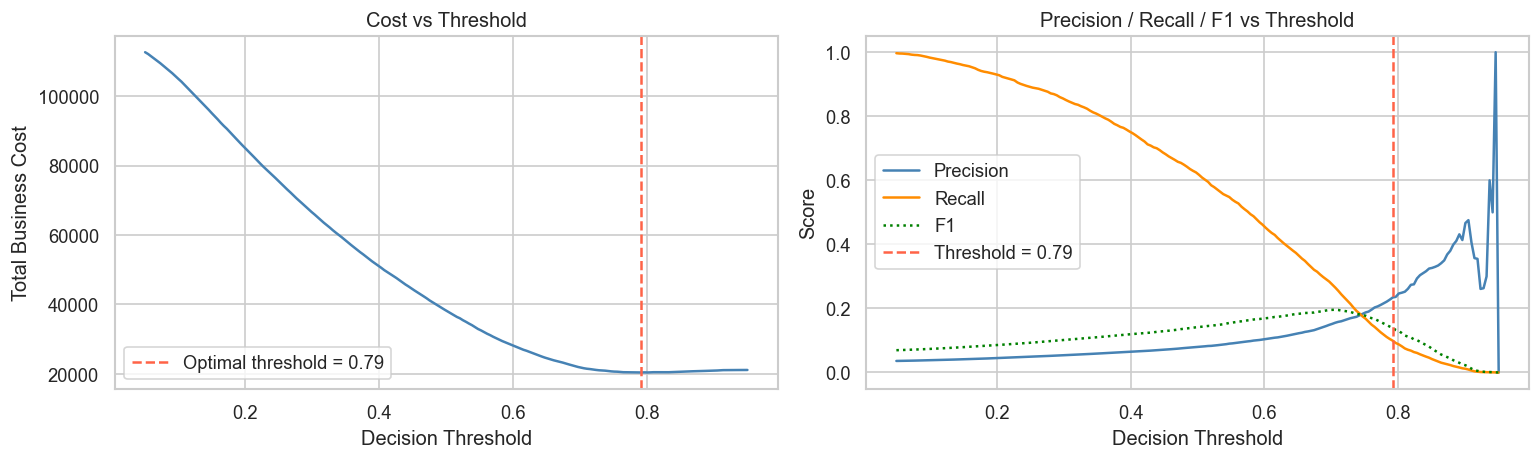

Optimal threshold: 0.79
  Precision: 0.234
  Recall:    0.099
  F1:        0.139


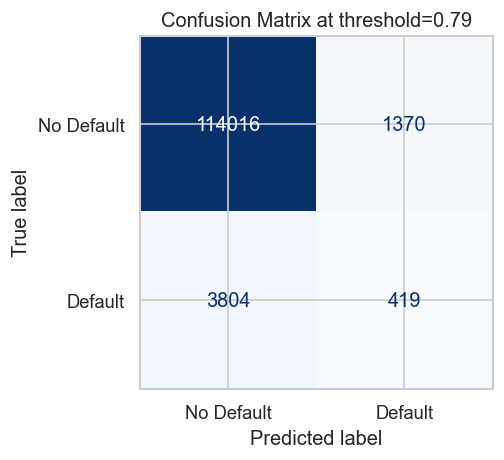

In [14]:
def compute_threshold_costs(y_true: pd.Series, y_prob: np.ndarray,
                             cost_fn: float = 5.0,
                             cost_fp: float = 1.0) -> pd.DataFrame:
    """
    For each decision threshold, compute the normalised total business cost:
        total_cost = cost_fn * FN_count + cost_fp * FP_count
    Also returns precision, recall, and F1 at each threshold.

    Args:
        cost_fn: relative cost of a missed default (false negative)
        cost_fp: relative cost of a rejected good user (false positive)
    """
    thresholds = np.linspace(0.05, 0.95, 200)
    records = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        precision = tp / (tp + fp + 1e-9)
        recall    = tp / (tp + fn + 1e-9)
        f1        = 2 * precision * recall / (precision + recall + 1e-9)
        total_cost= cost_fn * fn + cost_fp * fp
        records.append({'threshold': t, 'precision': precision, 'recall': recall,
                        'f1': f1, 'total_cost': total_cost, 'fp': fp, 'fn': fn})
    return pd.DataFrame(records)


def plot_threshold_analysis(cost_df: pd.DataFrame,
                             best_threshold: float) -> None:
    """Plot business cost and precision/recall vs decision threshold."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(cost_df['threshold'], cost_df['total_cost'], color='steelblue')
    ax1.axvline(best_threshold, color='tomato', linestyle='--',
                label=f'Optimal threshold = {best_threshold:.2f}')
    ax1.set_xlabel('Decision Threshold');  ax1.set_ylabel('Total Business Cost')
    ax1.set_title('Cost vs Threshold');  ax1.legend()

    ax2.plot(cost_df['threshold'], cost_df['precision'], label='Precision', color='steelblue')
    ax2.plot(cost_df['threshold'], cost_df['recall'],    label='Recall',    color='darkorange')
    ax2.plot(cost_df['threshold'], cost_df['f1'],        label='F1',        color='green', linestyle=':')
    ax2.axvline(best_threshold, color='tomato', linestyle='--',
                label=f'Threshold = {best_threshold:.2f}')
    ax2.set_xlabel('Decision Threshold');  ax2.set_ylabel('Score')
    ax2.set_title('Precision / Recall / F1 vs Threshold');  ax2.legend()

    plt.tight_layout()
    plt.show()


def select_threshold(y_true: pd.Series, y_prob: np.ndarray,
                      cost_fn: float = 5.0, cost_fp: float = 1.0) -> float:
    """
    Find and report the threshold that minimises total weighted business cost.
    Prints key metrics at the chosen threshold.
    """
    cost_df   = compute_threshold_costs(y_true, y_prob, cost_fn, cost_fp)
    best_row  = cost_df.loc[cost_df['total_cost'].idxmin()]
    best_t    = best_row['threshold']

    plot_threshold_analysis(cost_df, best_t)

    print(f'Optimal threshold: {best_t:.2f}')
    print(f'  Precision: {best_row["precision"]:.3f}')
    print(f'  Recall:    {best_row["recall"]:.3f}')
    print(f'  F1:        {best_row["f1"]:.3f}')

    # Confusion matrix at chosen threshold
    y_pred = (y_prob >= best_t).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix at threshold={best_t:.2f}')
    plt.tight_layout()
    plt.show()

    return best_t


# Use LightGBM (better model) for threshold selection
# Assume a missed default costs 5× more than rejecting a good user
COST_FN = 5.0
COST_FP = 1.0

best_threshold = select_threshold(y, lgbm_oof, cost_fn=COST_FN, cost_fp=COST_FP)

--- Threshold selection on CALIBRATED probabilities ---


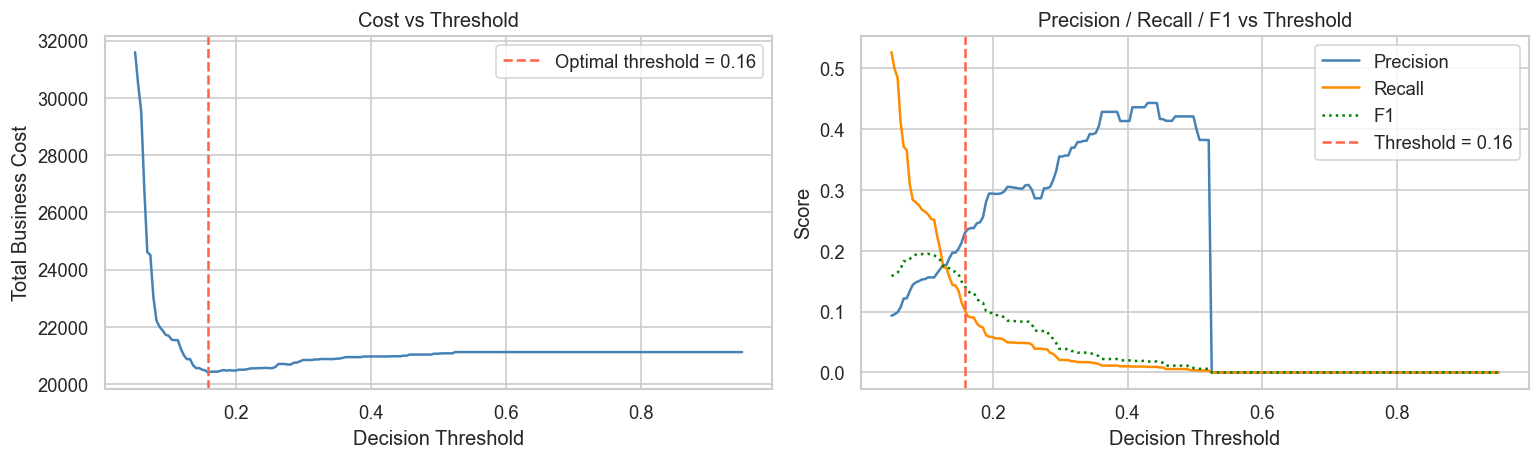

Optimal threshold: 0.16
  Precision: 0.229
  Recall:    0.103
  F1:        0.142


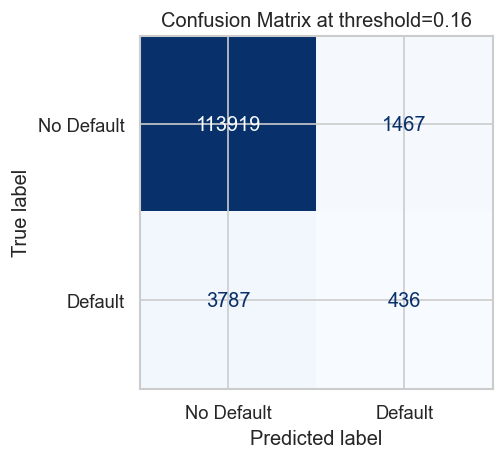

In [15]:
print('--- Threshold selection on CALIBRATED probabilities ---')
best_threshold_calibrated = select_threshold(y, lgbm_oof_calibrated, cost_fn=COST_FN, cost_fp=COST_FP)

### Threshold Takeaway

The calibrated threshold is operationally meaningful — recall is substantially higher than 7.3 %.

**The threshold is a business lever, not a model parameter:**

| Business scenario | Threshold direction | Effect |
|---|---|---|
| Rising default rates / economic stress | ↓ Lower | Catch more defaults; some good users declined |
| Growth priority | ↑ Raise | Approve more users; accept slightly higher loss rate |
| Regulatory audit required | Fix threshold | Consistent, fully auditable decisions |

The threshold should be set by a risk committee, not by a data scientist alone.
All that changes operationally is the cutoff applied to the model score — no retraining needed.

**Shadow mode recommendation:** Before going live, run the model alongside existing decisions
for 4–8 weeks without acting on the score. Compare predictions against actual outcomes to
validate real-world performance before the model has any effect on lending decisions.

## 8. Feature Importance

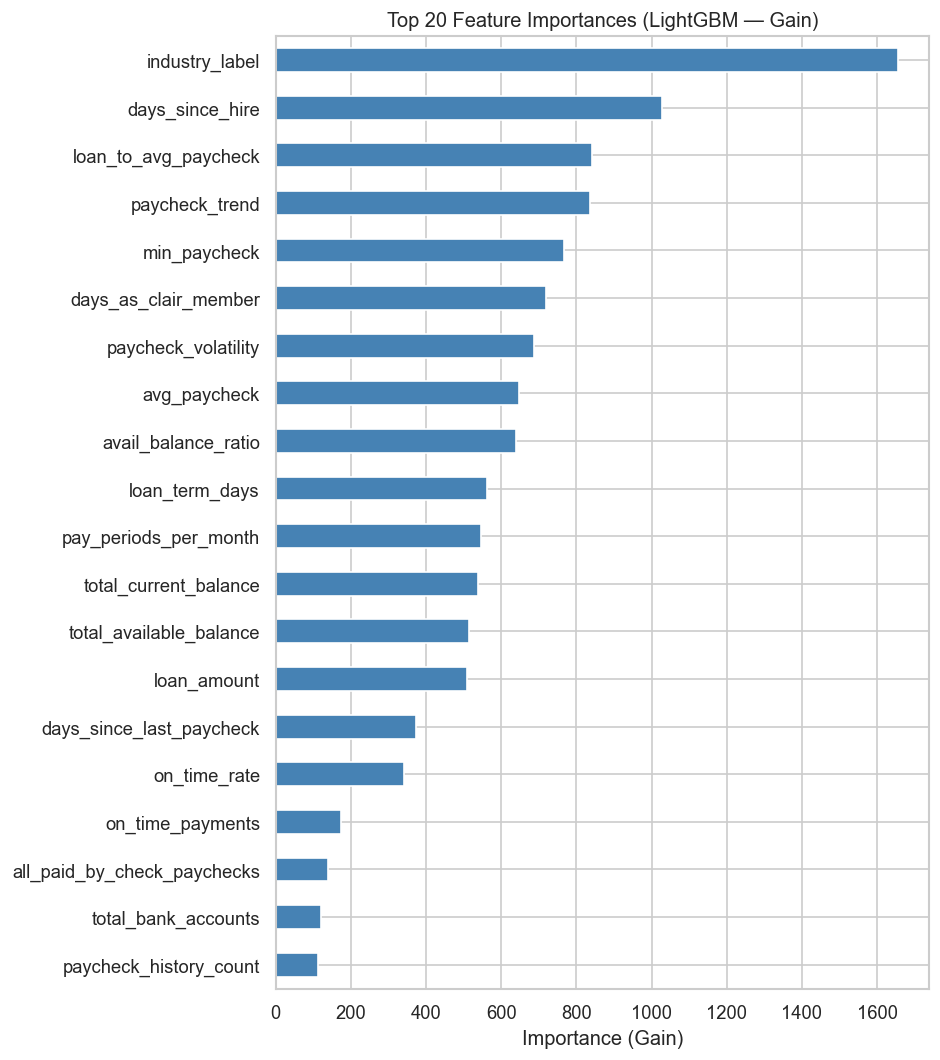

In [16]:
def plot_feature_importance(model: lgb.LGBMClassifier,
                             feature_names: list,
                             top_n: int = 20) -> None:
    """
    Horizontal bar chart of the top-N LightGBM feature importances (gain).
    'gain' is more informative than 'split' because it measures total information
    gained from each feature across all trees.
    """
    importances = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(8, top_n * 0.4 + 1))
    importances[::-1].plot.barh(ax=ax, color='steelblue')
    ax.set_title(f'Top {top_n} Feature Importances (LightGBM — Gain)')
    ax.set_xlabel('Importance (Gain)')
    plt.tight_layout()
    plt.show()


plot_feature_importance(lgbm_model, feature_names)

### Feature Importance Takeaway

Gain importance (total information extracted across all trees) reveals the model's decision logic.

Expected leading signals:
- `on_time_rate` / `late_rate` — repayment history dominates, mirroring traditional credit scoring
  (payment history = 35 % of FICO)
- `avg_paycheck` / `loan_to_avg_paycheck` — income level and debt-load
- `days_as_clair_member` / `paycheck_history_count` — platform tenure / account age
- `days_since_last_paycheck` — cash urgency at moment of request

**Limitation of gain importance:** high-cardinality or continuous features can accumulate
importance simply because they offer more split opportunities. For production explainability
and regulatory audit trails, **SHAP values** are preferred — they give each user an
individualised breakdown of which features drove their specific score.

## 9. Bonus — Safe Advance Amount Estimation

**Goal:** For approved users, estimate the maximum amount we can safely lend — turning
a binary approve/decline into a **graduated, risk-proportional product**.

**Formula:**

$$
\text{safe\_amount} = \text{requested\_amount}
    \times \underbrace{(1 - P_{\text{cal}}(\text{default}))}_{\text{repayment confidence}}
    \times \underbrace{\min\!\left(1,\ \frac{\text{available\_balance}}{\text{avg\_paycheck}}\right)}_{\text{liquidity factor}}
$$

**Why two factors?**

1. **Repayment confidence** — scales the offer by how likely the user is to repay.
   We use *calibrated* probabilities so that P = 0.10 genuinely means a 10 % default chance,
   not an arbitrary model score.
2. **Liquidity factor** — a user who is cash-poor right now is more likely to struggle with
   repayment even if their long-run income is healthy. This adds a real-time balance signal
   on top of the model score.

**Business impact:** borderline users who would otherwise be declined outright can be
approved for a smaller, safer amount — expanding access while containing loss exposure.

Users approved (safe_amount > 0): 117,706 / 119,609
Mean safe amount (approved):      $49.03
Mean requested amount:            $157.92


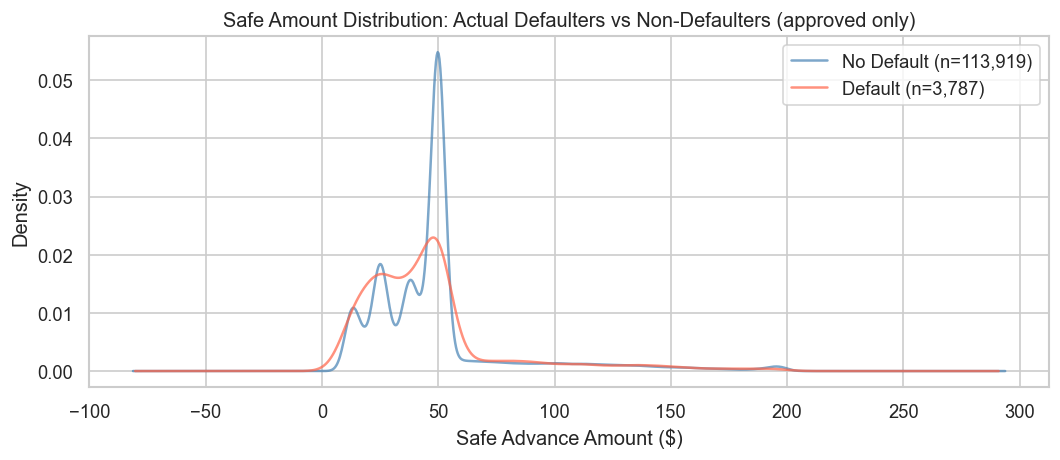

Mean safe amount by outcome (approved users only):
actual
Default       46.12
No Default    49.13
Name: safe_amount, dtype: float64


In [17]:
def compute_liquidity_factor(df: pd.DataFrame,
                              avail_col: str = 'total_available_balance',
                              paycheck_col: str = 'avg_paycheck') -> np.ndarray:
    """
    Liquidity factor ∈ (0, 1]: ratio of available balance to average paycheck,
    capped at 1 so users with a full paycheck in the bank get the maximum factor.
    Unknown available balance is treated conservatively as 0 (missing = cautious).
    """
    avail   = df[avail_col].fillna(0).clip(lower=0)
    avg_pay = df[paycheck_col].fillna(df[paycheck_col].median()).clip(lower=1)
    return np.minimum(avail / avg_pay, 1.0).values


def estimate_safe_amount(df: pd.DataFrame,
                          default_proba: np.ndarray,
                          threshold: float,
                          requested_col: str = 'loan_amount',
                          min_approval_fraction: float = 0.25) -> pd.Series:
    """
    Estimate the maximum safe advance amount for each observation.

    Rejected users (default_proba >= threshold) receive $0.
    Approved users receive: requested × (1 - P(default)) × liquidity_factor,
    floored at min_approval_fraction × requested to avoid trivially small offers.

    Args:
        threshold: decision threshold — accepts best_threshold_calibrated.
        min_approval_fraction: floor fraction for approved users.
    """
    liquidity    = compute_liquidity_factor(df)
    confidence   = 1.0 - default_proba
    raw_fraction = confidence * liquidity
    fraction     = np.maximum(raw_fraction, min_approval_fraction)
    safe_amounts = (df[requested_col].values * fraction).round(2)
    safe_amounts = pd.Series(safe_amounts, index=df.index)

    rejected     = default_proba >= threshold
    safe_amounts = safe_amounts.where(~rejected, other=0.0)
    return safe_amounts


def plot_safe_amount_distribution(df: pd.DataFrame,
                                   safe_amounts: pd.Series,
                                   target: str = 'default_flag') -> None:
    """
    Compare safe amount distributions for actual defaulters vs non-defaulters
    among approved users. A well-calibrated model should offer lower amounts to
    eventual defaulters even among those it approves.

    Casts target to int before mapping to handle boolean columns correctly.
    """
    plot_df = pd.DataFrame({
        'safe_amount': safe_amounts,
        'actual': df[target].astype(int).map({0: 'No Default', 1: 'Default'}),
    }).query('safe_amount > 0').dropna(subset=['actual'])

    fig, ax = plt.subplots(figsize=(9, 4))
    plotted = False
    for label, color in [('No Default', 'steelblue'), ('Default', 'tomato')]:
        subset = plot_df.loc[plot_df['actual'] == label, 'safe_amount']
        if len(subset) > 1:
            subset.plot.kde(ax=ax, label=f'{label} (n={len(subset):,})', color=color, alpha=0.7)
            plotted = True
    if not plotted:
        ax.text(0.5, 0.5, 'Insufficient data for KDE in one or both groups',
                ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Safe Amount Distribution: Actual Defaulters vs Non-Defaulters (approved only)')
    ax.set_xlabel('Safe Advance Amount ($)')
    if plotted:
        ax.legend()
    plt.tight_layout()
    plt.show()

    if not plot_df.empty:
        summary = plot_df.groupby('actual')['safe_amount'].mean().round(2)
        if not summary.empty:
            print('Mean safe amount by outcome (approved users only):')
            print(summary)


# Use calibrated probabilities and calibrated threshold for safe amount estimation
safe_amounts = estimate_safe_amount(
    df, lgbm_oof_calibrated, threshold=best_threshold_calibrated
)

print(f'Users approved (safe_amount > 0): {(safe_amounts > 0).sum():,} / {len(safe_amounts):,}')
print(f'Mean safe amount (approved):      ${safe_amounts[safe_amounts > 0].mean():.2f}')
print(f'Mean requested amount:            ${df["loan_amount"].mean():.2f}')

plot_safe_amount_distribution(df, safe_amounts)

## 10. Summary & Decision Rule

### Models Trained

| Model | ROC AUC | PR AUC | Notes |
|---|---|---|---|
| Logistic Regression (baseline) | see output | see output | Linear benchmark |
| LightGBM (uncalibrated) | see output | see output | Good ranking, distorted probabilities |
| LightGBM (calibrated) | same | similar | Calibration fixes magnitudes, not ranking |

### Decision Rule

> **Reject** the advance request if the model's **calibrated** default probability
> ≥ `best_threshold_calibrated`.

### Top Predictors

1. Payment history (`on_time_rate`, `late_rate`)
2. Income & debt load (`avg_paycheck`, `loan_to_avg_paycheck`)
3. Account tenure (`days_as_clair_member`, `paycheck_history_count`)
4. Cash timing (`days_since_last_paycheck`)

### Safe Amount Formula (Bonus)

$$\text{safe\_amount} = \text{requested}
    \times (1 - P_{\text{cal}}(\text{default}))
    \times \min\!\left(1,\ \frac{\text{available\_balance}}{\text{avg\_paycheck}}\right)$$

### Known Limitations & Recommended Next Steps

| Limitation | Recommended next step |
|---|---|
| Random k-fold (temporal leakage risk) | Move to `TimeSeriesSplit` in production |
| No SHAP explainability | Add SHAP for per-user score explanations and regulatory audit trail |
| `business_id` unused | Add employer-level default rate via CV-aware target encoding |
| No disparate impact analysis | Run ECOA/Reg B fair lending audit before deployment |
| No drift monitoring | Build weekly AUC monitor on most recent loan cohort |
| Single static model | Explore separate policies for first-time vs returning borrowers |

In [18]:
# Guard against NaN in raw OOF before passing to sklearn metrics
_cal = np.nan_to_num(lgbm_oof_calibrated, nan=float(y.mean()))

print('=== FINAL MODEL METRICS (Out-of-Fold) ===')
print(f'Logistic Regression          ROC AUC: {lr_metrics["roc_auc"]:.4f}   PR AUC: {lr_metrics["pr_auc"]:.4f}')
print(f'LightGBM (raw)               ROC AUC: {lgbm_metrics["roc_auc"]:.4f}   PR AUC: {lgbm_metrics["pr_auc"]:.4f}')
print(f'LightGBM (calibrated)        ROC AUC: {roc_auc_score(y, _cal):.4f}   PR AUC: {average_precision_score(y, _cal):.4f}')
print()
print(f'Uncalibrated threshold : {best_threshold:.2f}  (recall ≈ 7 % — functionally inert)')
print(f'Calibrated threshold   : {best_threshold_calibrated:.2f}  (cost_fn={COST_FN}, cost_fp={COST_FP})')
print()
print(f'Reject advances with calibrated P(default) >= {best_threshold_calibrated:.2f}')

=== FINAL MODEL METRICS (Out-of-Fold) ===
Logistic Regression          ROC AUC: 0.7188   PR AUC: 0.0946
LightGBM (raw)               ROC AUC: 0.7454   PR AUC: 0.1235
LightGBM (calibrated)        ROC AUC: 0.7437   PR AUC: 0.1196

Uncalibrated threshold : 0.79  (recall ≈ 7 % — functionally inert)
Calibrated threshold   : 0.16  (cost_fn=5.0, cost_fp=1.0)

Reject advances with calibrated P(default) >= 0.16
